# Lab 1 Task 1.1: Simple ANN for Sentiment Analysis
**Dataset:** Amazon Polarity (Negative = 0, Positive = 1)

---

## Objective
Build and train a feed-forward Artificial Neural Network (ANN) for text sentiment classification.  
The network learns its own text representations through an Embedding layer.

**Pipeline:**
Raw data  →  Tokenise  →  Word indices  →  Embedding layer  →  Mean pool  →  FC layers  →  Prediction

Steps in this notebook:
1. Load and explore the Amazon Polarity dataset.
2. Build a simple word level tokeniser and vocabulary.
3. Design a neural network with a learned Embedding layer + fully-connected layers.
4. Train with proper train / val / test splits.
5. Evaluate and interpret classification metrics.

> Change SUBSET_SIZE = 25_000 to SUBSET_SIZE = None to use the full 1GB Dataset


In [ ]:
import sys, os, re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Make data_pipeline.py and config.py importable
sys.path.insert(0, os.path.abspath('.'))
from data_pipeline import load_and_split, set_seed
from config import SEED, NUM_LABELS

set_seed(SEED)  # fix all random seeds for reproducibility

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Random seed : {SEED}")
print(f"Running on  : {DEVICE}")


Random seed : 42
Running on  : cpu


## Step 1: Load the Dataset

We use the **shared team data pipeline** which:
- Downloads *Amazon Polarity* from Hugging Face Hub.
- Applies light cleaning (strips HTML tags, URLs, emails).
- Creates a stratified 80 / 10 / 10 train / val / test split.


In [ ]:
# ---------------------------------------------------------------
# SUBSET_SIZE = 25_000  ->  fast testing
# SUBSET_SIZE = None    ->  full 3.6 M rows
# ---------------------------------------------------------------
SUBSET_SIZE = None

splits = load_and_split(subset_size=SUBSET_SIZE, seed=SEED)

train_texts  = splits['train']['texts']
train_labels = splits['train']['labels']
val_texts    = splits['val']['texts']
val_labels   = splits['val']['labels']
test_texts   = splits['test']['texts']
test_labels  = splits['test']['labels']

print(f"\nSplit sizes:")
print(f"  Train : {len(train_texts):>7,} samples")
print(f"  Val   : {len(val_texts):>7,} samples")
print(f"  Test  : {len(test_texts):>7,} samples")

neg = train_labels.count(0) if isinstance(train_labels, list) else int((np.array(train_labels)==0).sum())
pos = train_labels.count(1) if isinstance(train_labels, list) else int((np.array(train_labels)==1).sum())
print(f"\nClass balance (train): Negative = {neg:,} | Positive = {pos:,}")



Split sizes:
  Train : 2,880,000 samples
  Val   : 360,000 samples
  Test  : 360,000 samples

Class balance (train): Negative = 1,440,000 | Positive = 1,440,000


## Step 2: Tokenisation & Vocabulary

### What we do here
1. **Tokenise** - split each review into a list of lowercase words.
2. **Build a vocabulary** - assign a unique integer ID to every word that appears ≥ 2 times in the training set.
3. **Numericalize & pad** - convert each review to a fixed-length integer sequence (MAX_SEQ_LEN tokens).  
   - Short reviews are zero-padded on the right.  
   - Long reviews are truncated.

### Special tokens
| Token | ID | Meaning |
|---|---|---|
| PAD | 0 | Padding - ignored by the Embedding layer (padding_idx=0) |
| UNK | 1 | Unknown word - used for words not seen in training |

> **Key rule:** The vocabulary is built **only from the training set**.  
> This prevents data leakage - the model must not know anything about test vocabulary ahead of time.


In [3]:
MAX_SEQ_LEN = 200   # tokens per review (truncate longer, pad shorter)
MAX_VOCAB   = 20000  # keep only the top N most frequent words
MIN_FREQ    = 2     # ignore words appearing fewer than 2 times

def tokenise(text):
    """Lowercase and split on non-alphabetic characters."""
    return re.findall(r'[a-z]+', text.lower())

# Build vocabulary from TRAINING data only
counter = Counter()
for text in train_texts:
    counter.update(tokenise(text))

# Special tokens first: 0=PAD, 1=UNK
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, freq in counter.most_common(MAX_VOCAB):
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Vocabulary size : {VOCAB_SIZE:,} (capped at {MAX_VOCAB:,}, min freq={MIN_FREQ})")

# Convert texts to padded integer arrays
def texts_to_array(texts, vocab, max_len=MAX_SEQ_LEN):
    """
    Convert a list of raw text strings to a 2D numpy array of shape [N, max_len].
    Each row is the token-ID sequence for one review, zero-padded or truncated to max_len.
    """
    arr = np.zeros((len(texts), max_len), dtype=np.int64)
    for i, text in enumerate(texts):
        ids = [vocab.get(tok, vocab['<UNK>']) for tok in tokenise(text)[:max_len]]
        arr[i, :len(ids)] = ids
    return arr

X_train = texts_to_array(train_texts, vocab)
X_val   = texts_to_array(val_texts,   vocab)
X_test  = texts_to_array(test_texts,  vocab)

y_train = np.array(train_labels, dtype=np.int64)
y_val   = np.array(val_labels,   dtype=np.int64)
y_test  = np.array(test_labels,  dtype=np.int64)

print(f"X_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")

# Show one example: raw text → token IDs
example_tokens = tokenise(train_texts[0])[:10]
example_ids    = [vocab.get(t, 1) for t in example_tokens]
print(f"\nExample tokenisation:")
print(f"  Tokens : {example_tokens}")
print(f"  IDs    : {example_ids}")


Vocabulary size : 20,002 (capped at 20,000, min freq=2)
X_train shape : (2880000, 200)
X_val   shape : (360000, 200)
X_test  shape : (360000, 200)

Example tokenisation:
  Tokens : ['in', 'my', 'case', 'i', 've', 'used', 'it', 'as', 'part', 'of']
  IDs    : [11, 24, 350, 3, 111, 139, 7, 25, 249, 8]


## Step 3: Wrap in DataLoaders

DataLoader handles mini-batch creation, optional shuffling, and efficient data transfer to the GPU.

- **Training loader:** shuffle=True - randomises sample order each epoch to prevent the model  
  from memorising the order of examples.
- **Val / Test loaders:** no shuffle - order doesn't matter for evaluation.


In [4]:
BATCH_SIZE = 512

def make_loader(X, y, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        pin_memory=(DEVICE.type == 'cuda'),  # speeds up CPU→GPU transfer
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)

print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Batch size    : 512
Train batches : 5625
Val batches   : 704
Test batches  : 704


## Step 4: Model Architecture

### How word embeddings work
An **Embedding layer** is essentially a lookup table:
- It has one row per word in the vocabulary (shape: `[VOCAB_SIZE, EMBED_DIM]`).
- Given a token ID, it returns the corresponding row - a dense vector of `EMBED_DIM` numbers.
- These vectors are **randomly initialised** and then **learned during training**.

### Mean pooling
Since reviews have different lengths, we average the embeddings of all tokens in a review  
to get a single fixed-size vector - this is the input to the fully-connected layers.

### Full architecture
```
Input: token IDs  [batch, 200]
  |
  Embedding(VOCAB_SIZE, 128, padding_idx=0)
  |    → [batch, 200, 128]  (128-dim vector per token)
  |
  Mean over sequence dimension
  |    → [batch, 128]  (one vector per review)
  |
  Linear(128→256) → BatchNorm1d → ReLU → Dropout(0.4)
  |
  Linear(256→128) → BatchNorm1d → ReLU → Dropout(0.4)
  |
  Linear(128→64) → ReLU
  |
  Linear(64→2)   ← raw logits (CrossEntropyLoss handles softmax)
```

### Layer roles
| Layer | Role |
|---|---|
| `nn.Embedding` | Lookup table: integer ID → dense vector. Learned during training. |
| Mean pooling | Collapses variable-length sequences into one fixed-size vector |
| `nn.BatchNorm1d` | Normalises activations across the batch - stabilises and speeds up training |
| `nn.ReLU` | Non-linear activation: f(x)=max(0,x). Without this, stacking linear layers is equivalent to just one linear layer |
| `nn.Dropout(p)` | Randomly zeroes p% of activations during training - reduces overfitting |


In [69]:
EMBED_DIM = 128  # size of each word embedding vector

class SentimentANN(nn.Module):
    """
    ANN for binary sentiment classification.
    Pipeline: token IDs -> Embedding -> mean pool -> FC layers -> logits
    """

    def __init__(self, vocab_size, embed_dim, num_classes=2, dropout=0.4):
        super().__init__()

        # Embedding lookup table — padding_idx=0 means PAD tokens contribute 0
        # to the mean, so they don't influence the representation
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.fc = nn.Sequential(
            # Block 1
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 3
            nn.Linear(128, 64),
            nn.ReLU(),
            # Output — raw logits, no softmax (CrossEntropyLoss does it internally)
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: [batch, seq_len]  (integer token IDs)
        embedded = self.embedding(x)       # [batch, seq_len, embed_dim]

        # Mean pooling: average over the sequence dimension
        # Ignores padding (zeros don't shift the mean much for long sequences)
        pooled = embedded.mean(dim=1)      # [batch, embed_dim]

        return self.fc(pooled)             # [batch, num_classes]


model = SentimentANN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_classes=NUM_LABELS,
).to(DEVICE)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {n_params:,}")


SentimentANN(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total trainable parameters: 2,635,330


## Step 5: Training Setup

### Loss - CrossEntropyLoss
- Standard loss for classification tasks.
- Internally applies softmax then computes negative log-likelihood.
- **Do not** add a softmax to the model output - that would apply it twice.

### Optimiser - Adam
- Adaptive per-parameter learning rates (combines momentum + RMSProp).
- A fixed learning rate of `1e-4` is used throughout training.


In [6]:
EPOCHS        = 5
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


## Step 6: Training Loop

Each **epoch** has two phases:

| Phase | model.train() | Gradients | Weights updated? |
|---|---|---|---|
| Training | Yes | Computed | Yes |
| Validation | No (model.eval()) | Not computed | No |

We save the **best checkpoint** -the model weights that gave the highest validation accuracy.  
This is what we restore for final testing.


In [ ]:
def run_epoch(loader, model, criterion, optimizer=None):
    """
    One pass over all batches in `loader`.
    - If optimizer is provided: training mode (forward + backward + weight update).
    - If optimizer is None: evaluation mode (forward only, no gradient computation).
    Returns: (average_loss, accuracy)
    """
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds  = []
    all_true   = []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)   # token IDs:  [batch, seq_len]
            y_batch = y_batch.to(DEVICE)   # labels:     [batch]

            logits = model(X_batch)        # [batch, 2]
            loss   = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad()  # clear gradients from previous step
                loss.backward()        # compute gradients (backpropagation)
                optimizer.step()       # update weights using Adam

            total_loss += loss.item() * len(y_batch)
            preds = logits.argmax(dim=1)   # class with highest logit
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_true, all_preds)
    return avg_loss, acc


#Training
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc     = 0.0
best_model_state = None

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>10} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(val_loader,   model, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.2%} | {val_loss:>8.4f} | {val_acc:>7.2%}")

print(f"\nTraining complete.  Best validation accuracy: {best_val_acc:.2%}")


 Epoch | Train Loss |  Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     0.4226 |    80.12% |   0.3247 |  85.89%
     2 |     0.3104 |    86.80% |   0.2889 |  87.75%
     3 |     0.2873 |    87.95% |   0.2769 |  88.31%
     4 |     0.2772 |    88.44% |   0.2711 |  88.66%
     5 |     0.2714 |    88.73% |   0.2673 |  88.86%

Training complete.  Best validation accuracy: 88.86%


## Step 7: Evaluate on the Test Set

We restore the **best checkpoint** and run it on the held-out test set - data the model  
has never seen during training or hyperparameter tuning.

### Metrics
| Metric | Formula | What it tells you |
|---|---|---|
| Accuracy | correct / total | Overall fraction correct |
| Precision | TP / (TP+FP) | Of all predicted positive, how many were truly positive? |
| Recall | TP / (TP+FN) | Of all actual positive, how many did we catch? |
| F1-Score | 2·P·R / (P+R) | Harmonic mean — good summary when classes may be imbalanced |


In [8]:
# Restore the best weights before evaluating
model.load_state_dict(best_model_state)
model.eval()

all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

print(classification_report(all_true, all_preds, target_names=['Negative', 'Positive']))

print(f"Accuracy  : {accuracy_score(all_true, all_preds):.2%}")
print(f"Precision : {precision_score(all_true, all_preds, average='weighted'):.2%}  (weighted)")
print(f"Recall    : {recall_score(all_true,    all_preds, average='weighted'):.2%}  (weighted)")
print(f"F1-Score  : {f1_score(all_true,        all_preds, average='weighted'):.2%}  (weighted)")


              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89    180000
    Positive       0.89      0.89      0.89    180000

    accuracy                           0.89    360000
   macro avg       0.89      0.89      0.89    360000
weighted avg       0.89      0.89      0.89    360000

Accuracy  : 88.87%
Precision : 88.87%  (weighted)
Recall    : 88.87%  (weighted)
F1-Score  : 88.87%  (weighted)


## Step 8: Visualise Training Progress

- **Loss curve:** both train and val loss should decrease. If val loss starts rising while  
  train loss keeps falling → **overfitting**.
- **Accuracy curve:** increasing for both. A large train-val gap → overfitting.
- **Confusion matrix:** reveals which class the model struggles with more.


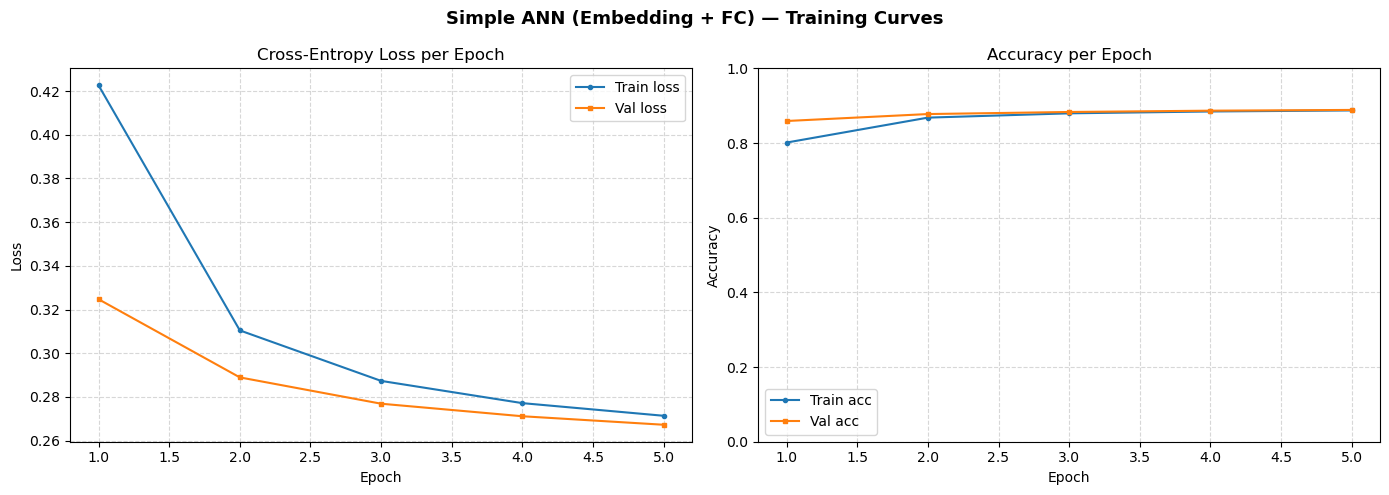

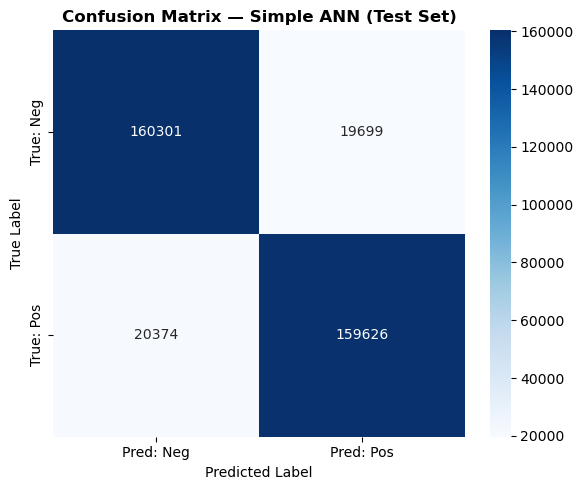

Plots saved.


In [9]:
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_x, history['train_loss'], 'o-', markersize=3, label='Train loss')
axes[0].plot(epochs_x, history['val_loss'],   's-', markersize=3, label='Val loss')
axes[0].set_title('Cross-Entropy Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Accuracy
axes[1].plot(epochs_x, history['train_acc'], 'o-', markersize=3, label='Train acc')
axes[1].plot(epochs_x, history['val_acc'],   's-', markersize=3, label='Val acc')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Simple ANN (Embedding + FC) — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('simple_ann_training_curves.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig2, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Neg', 'Pred: Pos'],
    yticklabels=['True: Neg', 'True: Pos'],
    ax=ax,
)
ax.set_title('Confusion Matrix — Simple ANN (Test Set)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('simple_ann_confusion_matrix.png', dpi=150)
plt.show()
print("Plots saved.")
